In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logging
import warnings
from pathlib import Path
from scipy.optimize import minimize
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AffinityPropagation
from scipy.spatial.distance import cdist
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score
import shap
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
log = logging.getLogger(__name__)

# Import data

In [2]:
# ── 1. Laden & Datum konvertieren ──────────────────────────────────────
analysis_df = pd.read_excel('analysis_df.xlsx')

analysis_df['TIME'] = pd.to_datetime(
    analysis_df['TIME'].str.replace('-M', '-', regex=False),
    format='%Y-%m'
)

In [3]:
# drop countries with specific debt information
countries_to_drop = [
    'Congo, Dem. Rep. (Zaire)',
    'Congo, Rep.',
    'Dominican Rep.',
    'Dominican Rep. (bond debt)',
    'Dominican Rep. (bank debt)',
    'Ethopia',
    'Gambia,The',
    'Moldova (Gazprom debt)',
    'Mozambique (EMATUM Notes)',
    'Mozambique (Eurobonds)',
    'Other Countries n.i.e.',
    'Pakistan (bond debt)',
    'Panama (bond debt)',
    'Russia (GKOs, non-resid.)',
    'Russia (MinFin3)',
    'Russia (PRINs & IANs)',
    'Ukraine (Commercial loans)',
    'Ukraine (Eurobonds)',
    'Ukraine (Global Exchange)',
    'Ukraine (ING debt / Merrill Lynch)',
    'Ukraine (OVDPs, non-resid.)'
]
analysis_df = analysis_df[~analysis_df['COUNTRY'].isin(countries_to_drop)]

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 1: Feature Engineering – Modell-Features
# Leakage-Regeln:
#   GS10:         Lag 1 als Minimum (Marktdaten, konservativ)
#   CPI, ER:      Lag 3 als Minimum (1–3 Monate Verzug)
#   DEBT_GDP:     Lag 12 als Minimum (12–18 Monate Verzug)
#   EXPORTS:      Lag 12 als Minimum (12–18 Monate Verzug)
# ══════════════════════════════════════════════════════════════════════════════

analysis_df = analysis_df.sort_values(['COUNTRY', 'TIME']).reset_index(drop=True)

# ── Debt/GDP ──────────────────────────────────────────────────────────────────
analysis_df['debt_gdp_lag12'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(12)
)
analysis_df['debt_gdp_lag24'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(24)
)

# Lag 1: sicherster Ansatz (1 Monat Verzug)
analysis_df['debt_gdp_change'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP']
    .diff(12)
    .shift(1)   # DEBT_GDP_{t-1} - DEBT_GDP_{t-13}
)

analysis_df['debt_gdp_change_24'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].diff(24)
    .shift(12)    # shift(12) damit auch diff(24) kein aktuelles DEBT_GDP nutzt
)

# Lag 12: konservativer Ansatz (12 Monate Verzug, Literaturstandard)
analysis_df['debt_gdp_change_lag12'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP']
    .diff(12)
    .shift(12)  # DEBT_GDP_{t-12} - DEBT_GDP_{t-24}
)

# Prozentuale Änderung
analysis_df['debt_gdp_change_12_pct'] = (
    analysis_df['debt_gdp_change'] / analysis_df['debt_gdp_lag24']
).clip(-2, 2)

# Gelagte Dynamik
analysis_df['debt_gdp_change_lag12'] = (
    analysis_df.groupby('COUNTRY')['debt_gdp_change'].shift(12)
)

# ── Exports ───────────────────────────────────────────────────────────────────
# lag 1 change
analysis_df['export_growth'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD']
    .pct_change(12, fill_method=None)
    .shift(1)   # (EXPORTS_{t-1} - EXPORTS_{t-13}) / EXPORTS_{t-13}
    .replace([np.inf, -np.inf], np.nan)
    .clip(-5, 5)
)

analysis_df['export_lag12'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(12)
)
analysis_df['export_lag24'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(24)
)

# Gelagte Wachstumsrate
analysis_df['export_growth_lag12'] = (
    analysis_df.groupby('COUNTRY')['export_growth'].shift(12)
)

# ── GS10 – Lag 1 als Minimum ─────────────────────────────────────────────────
# Alle GS10-Variablen basieren auf GS10_{t-1} oder früher

# Basisvariable: GS10 mit Lag 1
analysis_df['gs10_lag1'] = (
    analysis_df.groupby('COUNTRY')['GS10'].shift(1)
)

# Änderungen: diff über gelagte Werte
# gs10_change_12 = GS10_{t-1} - GS10_{t-13}
analysis_df['gs10_change_12'] = (
    analysis_df.groupby('COUNTRY')['GS10']
    .diff(12)
    .shift(1)   # GS10_{t-1} - GS10_{t-13}
)

analysis_df['gs10_change_6'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(6)
    )
)
analysis_df['gs10_change_3'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(3)
    )
)
analysis_df['gs10_change_1'] = (
    analysis_df.groupby('COUNTRY')['gs10_lag1'].transform(
        lambda x: x.diff(1)
    )
)

# Prozentuale GS10-Änderungen (basieren auf gs10_lag1 als Nenner)
for suffix, diff_col in [
    ('12', 'gs10_change_12'), ('6', 'gs10_change_6'),
    ('3',  'gs10_change_3'),  ('1', 'gs10_change_1'),
]:
    analysis_df[f'gs10_change_{suffix}_pct'] = (
        analysis_df[diff_col] / analysis_df['gs10_lag1']
    ).clip(-2, 2)

# Log-Differenz: log(GS10_{t-1} / GS10_{t-13})
analysis_df['gs10_log_diff_12'] = np.log(
    analysis_df['gs10_lag1'] /
    analysis_df.groupby('COUNTRY')['gs10_lag1'].shift(12)
)

# Volatilitäts-Dummy: gs10_change_1 > rolling std
rolling_std = (
    analysis_df.groupby('COUNTRY')['gs10_change_1']
    .transform(lambda x: x.rolling(36, min_periods=6).std())
)
analysis_df['gs10_std_dummy'] = (
    analysis_df['gs10_change_1'] > rolling_std
).astype(int)

# Asymmetrische Schocks
analysis_df['gs10_increase_12'] = (
    analysis_df['gs10_change_12'].clip(lower=0)
)
analysis_df['gs10_decrease_12'] = (
    analysis_df['gs10_change_12'].clip(upper=0).abs()
)

# ── CPI – Lag 3 als Minimum ───────────────────────────────────────────────────
for lag in [3, 6, 12, 24]:
    col = f'cpi{lag}'
    analysis_df[col] = (
        analysis_df.groupby('COUNTRY')['cpi'].shift(lag)
    )
    p99 = analysis_df[col].quantile(0.99)
    analysis_df[col] = analysis_df[col].clip(upper=p99)

# CPI-Wachstumsrate: cpi{t-3} vs. cpi{t-15}
analysis_df['cpi_change_12'] = (
    (analysis_df['cpi3'] - analysis_df['cpi12'])  # beide bereits gelaggt
    / analysis_df['cpi12'].abs()
).replace([np.inf, -np.inf], np.nan).clip(-2, 2)

# ── ER – Lag 3 als Minimum ────────────────────────────────────────────────────
for lag in [3, 6, 12, 24]:
    col = f'er_rate{lag}'
    analysis_df[col] = (
        analysis_df.groupby('COUNTRY')['er_rate'].shift(lag)
    )
    p99 = analysis_df[col].quantile(0.99)
    p01 = analysis_df[col].quantile(0.01)
    analysis_df[col] = analysis_df[col].clip(p01, p99)

# ── Log-Transformation: Export-Niveau ────────────────────────────────────────
# Exporte in absoluten Zahlen sind stark rechtsschief
# log1p(x) = log(1+x) → funktioniert auch wenn x=0
analysis_df['export_lag12_log'] = np.log1p(
    analysis_df['export_lag12'].clip(lower=0)
)
analysis_df['export_lag24_log'] = np.log1p(
    analysis_df['export_lag24'].clip(lower=0)
)

# ── Log-Transformation: CPI-Niveau ───────────────────────────────────────────
# CPI kann sehr groß sein (Hyperinflation), log glättet das
for lag in [3, 6, 12, 24]:
    col     = f'cpi{lag}'
    col_log = f'cpi{lag}_log'
    analysis_df[col_log] = np.log1p(
        analysis_df[col].clip(lower=0)
    )

# ── Log-Transformation: ER – nur wenn sinnvoll ───────────────────────────────
# Nach Clipping auf p01/p99 ist er_rate bereits weniger verzerrt
# Zusätzlich log-transformiert für Robustheit
for lag in [3, 6, 12, 24]:
    col     = f'er_rate{lag}'
    col_log = f'er_rate{lag}_log'
    # Nur wenn positive Werte vorliegen (nach Clipping)
    if analysis_df[col].min() > 0:
        analysis_df[col_log] = np.log(analysis_df[col])
    else:
        analysis_df[col_log] = np.log1p(
            analysis_df[col].clip(lower=0)
        )

# ── Kontrolle ─────────────────────────────────────────────────────────────────
log_cols = [c for c in analysis_df.columns if c.endswith('_log')]
print(f"Log-transformierte Variablen: {len(log_cols)}")
for col in log_cols:
    orig = col.replace('_log', '')
    if orig in analysis_df.columns:
        print(f"  {orig:<25} Skew vorher: "
              f"{analysis_df[orig].skew():>7.2f}  "
              f"nachher: {analysis_df[col].skew():>7.2f}")

# ── Interaktionsterme ─────────────────────────────────────────────────────────
# GS10-Schock × Verschuldungsniveau (beide gelaggt → kein Leakage)
analysis_df['gs10_x_debt_gdp'] = (
    analysis_df['gs10_change_12'] * analysis_df['debt_gdp_lag12']
)

# Nur positive GS10-Schocks × Verschuldung (vorzeichen-robust)
analysis_df['gs10_increase_x_debt'] = (
    analysis_df['gs10_increase_12'] * analysis_df['debt_gdp_lag12']
)

# ── Inspektion ────────────────────────────────────────────────────────────────
model_features = [
    # Logit-Features (BMA-validiert)
    'debt_gdp_lag12', 'debt_gdp_change',
    'export_lag12',   'export_growth',
    'gs10_change_12', 'gs10_x_debt_gdp',
    'cpi3',           'er_rate3',
    'export_lag12_log', 'export_lag24_log',
    'cpi3_log',       'cpi6_log',
    'cpi12_log',      'cpi24_log',
    'er_rate3_log',   'er_rate6_log',
    'er_rate12_log',  'er_rate24_log',
    # Zusätzliche XGBoost-Features
    'debt_gdp_lag24', 'debt_gdp_change_24', 'debt_gdp_change_12_pct',
    'debt_gdp_change_lag12',
    'export_lag24', 'export_growth_lag12',
    'gs10_lag1', 'gs10_change_6', 'gs10_change_3', 'gs10_change_1',
    'gs10_change_12_pct', 'gs10_log_diff_12', 'gs10_std_dummy',
    'gs10_increase_12', 'gs10_decrease_12', 'gs10_increase_x_debt',
    'cpi6', 'cpi12', 'er_rate6', 'er_rate12', 'cpi_change_12',
]

print("── Block 1: Modell-Features ─────────────────────────────────")
print(f"Definierte Features: {len(model_features)}")
missing_feats = [f for f in model_features if f not in analysis_df.columns]
if missing_feats:
    print(f"⚠ Fehlende Spalten: {missing_feats}")
else:
    print("✓ Alle Features vorhanden")

print(f"\nFehlende Werte:")
print(analysis_df[model_features].isnull().sum()[
    analysis_df[model_features].isnull().sum() > 0
].to_string())

print(f"\nDefault-Länder:  "
      f"{analysis_df[analysis_df['DEFAULT']==1]['COUNTRY'].nunique()}")
print(f"Nicht-Default:   "
      f"{analysis_df[analysis_df['DEFAULT']==0]['COUNTRY'].nunique()}")

Log-transformierte Variablen: 10
  export_lag12              Skew vorher:   24.71  nachher:    0.84
  export_lag24              Skew vorher:   25.38  nachher:    0.84
  cpi3                      Skew vorher:    0.70  nachher:   -1.72
  cpi6                      Skew vorher:    0.64  nachher:   -1.72
  cpi12                     Skew vorher:    0.50  nachher:   -1.72
  cpi24                     Skew vorher:    0.26  nachher:   -1.71
  er_rate3                  Skew vorher:    9.55  nachher:    1.59
  er_rate6                  Skew vorher:    9.53  nachher:    1.60
  er_rate12                 Skew vorher:    9.51  nachher:    1.62
  er_rate24                 Skew vorher:    9.53  nachher:    1.68
── Block 1: Modell-Features ─────────────────────────────────
Definierte Features: 39
✓ Alle Features vorhanden

Fehlende Werte:
debt_gdp_lag12            36816
debt_gdp_change           37273
export_lag12              21701
export_growth             22012
gs10_change_12             2557
gs10_x_d

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# BLOCK 2: Hilfs-Features – nicht in Logit oder XGBoost als Input
# Werden benötigt für:
#   - MATCHING_FEATURES_RF (Affinity Propagation / Donor Pool)
#   - RESIDUAL_VARS (SC-Zwilling)
#   - Visualisierung (Panel D: SC-Distanz über Zeit)
#   - Diagnoseplots (Default-Perioden markieren)
# ══════════════════════════════════════════════════════════════════════════════

# ── Für MATCHING_FEATURES_RF (Affinity Propagation) ──────────────────────────
# Niveau und kurzfristige Lags für Cluster-Bildung
analysis_df['debt_gdp_lag1'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(1)
)
analysis_df['export_lag1'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(1)
)
analysis_df['export_lag6'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(6)
)

# GS10-Lags für Matching (kurzfristig)
for lag in [1, 3, 6, 12, 24]:
    analysis_df[f'gs10_{lag}'] = (
        analysis_df.groupby('COUNTRY')['GS10'].shift(lag)
    )

# ── Für RESIDUAL_VARS (SC-Zwilling / Rolling Residuals) ──────────────────────
# Diese Variablen gehen in den SC-Fit ein, NICHT direkt ins Modell
# RESIDUAL_VARS = ["debt_gdp_change", "EXPORTS to WORLD", "er_rate", "cpi"]
# → "debt_gdp_change" bereits in Block 1 definiert
# → "EXPORTS to WORLD", "er_rate", "cpi" sind Rohdaten aus analysis_df
# → keine zusätzlichen Features nötig

# ── Für export_growth_lag1 (Visualisierung / Diagnostik) ─────────────────────
# Basiert auf lag1 und lag13 – nur für Diagnoseplot, nicht im Modell
analysis_df['export_lag13'] = (
    analysis_df.groupby('COUNTRY')['EXPORTS to WORLD'].shift(13)
)
analysis_df['export_growth_lag1'] = (
    analysis_df['export_lag1'] - analysis_df['export_lag13']
).replace([np.inf, -np.inf], np.nan)

# ── Für Diagnoseplots: debt_gdp_lag6 ─────────────────────────────────────────
# Nur für Panel D / SC-Distanz-Visualisierung
analysis_df['debt_gdp_lag6'] = (
    analysis_df.groupby('COUNTRY')['DEBT_GDP'].shift(6)
)

# ── Inspektion ────────────────────────────────────────────────────────────────
helper_features = [
    'debt_gdp_lag1', 'debt_gdp_lag6',
    'export_lag1', 'export_lag6', 'export_lag13', 'export_growth_lag1',
    'gs10_1', 'gs10_3', 'gs10_6', 'gs10_12', 'gs10_24',
]

print("── Block 2: Hilfs-Features ──────────────────────────────────")
print(f"Definierte Hilfs-Features: {len(helper_features)}")
print(f"\nVerwendungszweck:")
print("  MATCHING_FEATURES_RF:  debt_gdp_lag1, export_lag1, gs10_1–gs10_24")
print("  RESIDUAL_VARS:         DEBT_GDP, EXPORTS to WORLD, er_rate, cpi (Rohdaten)")
print("  Visualisierung:        export_growth_lag1, debt_gdp_lag6")
print()

# Gesamtübersicht
print("── Gesamtübersicht ──────────────────────────────────────────")
all_engineered = [c for c in analysis_df.columns
                  if c not in ['COUNTRY', 'TIME', 'DEFAULT',
                               'DEBT_GDP', 'EXPORTS to WORLD',
                               'GS10', 'er_rate', 'cpi',
                               'IMPORTS from WORLD']]
print(f"Gesamt engineerte Spalten: {len(all_engineered)}")
print(f"  Block 1 (Modell):        {len(model_features)}")
print(f"  Block 2 (Hilfe):         {len(helper_features)}")
print(f"\nDefault-Länder:  {analysis_df[analysis_df['DEFAULT']==1]['COUNTRY'].nunique()}")
print(f"Nicht-Default:   {analysis_df[analysis_df['DEFAULT']==0]['COUNTRY'].nunique()}")

── Block 2: Hilfs-Features ──────────────────────────────────
Definierte Hilfs-Features: 11

Verwendungszweck:
  MATCHING_FEATURES_RF:  debt_gdp_lag1, export_lag1, gs10_1–gs10_24
  RESIDUAL_VARS:         DEBT_GDP, EXPORTS to WORLD, er_rate, cpi (Rohdaten)
  Visualisierung:        export_growth_lag1, debt_gdp_lag6

── Gesamtübersicht ──────────────────────────────────────────
Gesamt engineerte Spalten: 61
  Block 1 (Modell):        39
  Block 2 (Hilfe):         11

Default-Länder:  67
Nicht-Default:   213


In [5]:
# ── Schritt 1: DEFAULT_DATABASE einlesen ─────────────────────────────────────
db = pd.read_excel('DEFAULT_DATABASE_edited.xlsx',
                   sheet_name='DATASET Defaults & Restruct.',
                   header=5)
db = db.iloc[:, 1:]
db.columns = ['case_nr','new_case','case_nr_ct','country_case','country','wdi',
               'start','end','alt_end',
               'strictly_pre','weakly_pre','post_default',
               'default_date','announcement','no_exact_start']
db = db[pd.to_numeric(db['case_nr'], errors='coerce').notna()].copy()
db['start']        = pd.to_datetime(db['start'],        errors='coerce')
db['end']          = pd.to_datetime(db['end'],           errors='coerce')
db['announcement'] = pd.to_datetime(db['announcement'], errors='coerce')
db['default_date'] = pd.to_datetime(db['default_date'], errors='coerce')

# Announcement nutzen wenn vorhanden, sonst Start
db['T0'] = db['announcement'].fillna(db['start'])
db['T0'] = db['T0'].dt.to_period('M').dt.to_timestamp()

In [6]:
# ── Schritt 2: Panel aufbauen ─────────────────────────────────────────────────
# Für jedes Event: expandiere auf monatliche Beobachtungen
panel_rows = []
for _, row in db.iterrows():
    country = str(row['country']).strip()
    t0      = row['T0']
    t_end   = row['end']

    if pd.isna(t0) or pd.isna(t_end):
        continue

    months = pd.date_range(t0, t_end, freq='MS')

    for i, m in enumerate(months):
        panel_rows.append({
            'COUNTRY':       country,
            'TIME':          m,
            'DEFAULT_DB':    1,
            'DEFAULT_ONSET': 1 if i == 0 else 0,
            'POST_DEFAULT':  int(row['post_default'] == 1),
            'STRICTLY_PRE':  int(row['strictly_pre'] == 1),
        })

default_panel = pd.DataFrame(panel_rows)

default_panel_agg = (
    default_panel
    .groupby(['COUNTRY', 'TIME'])
    .agg(
        DEFAULT_DB    = ('DEFAULT_DB',    'max'),
        DEFAULT_ONSET = ('DEFAULT_ONSET', 'max'),   # 1 wenn irgendein Event startet
        POST_DEFAULT  = ('POST_DEFAULT',  'max'),
        STRICTLY_PRE  = ('STRICTLY_PRE',  'max'),
    )
    .reset_index()
)

print(f"default_panel_agg: {len(default_panel_agg):,} Zeilen")
print(f"Länder im Panel:   {default_panel_agg['COUNTRY'].nunique()}")
print(f"Onset-Events:      {default_panel_agg['DEFAULT_ONSET'].sum()}")
print(f"Zeitraum:          {default_panel_agg['TIME'].min()} – {default_panel_agg['TIME'].max()}")


default_panel_agg: 6,606 Zeilen
Länder im Panel:   76
Onset-Events:      187
Zeitraum:          1976-03-01 00:00:00 – 2020-09-01 00:00:00


In [7]:
# ── Merge ─────────────────────────────────────────────────────────────────────
# Sicherstellen dass TIME in beiden DataFrames gleicher Typ
analysis_df['TIME'] = pd.to_datetime(analysis_df['TIME'])
default_panel_agg['TIME'] = pd.to_datetime(default_panel_agg['TIME'])

# Merge: LEFT JOIN damit alle analysis_df Zeilen erhalten bleiben
analysis_df = pd.merge(
    analysis_df,
    default_panel_agg[['COUNTRY', 'TIME',
                        'DEFAULT_DB', 'DEFAULT_ONSET',
                        'POST_DEFAULT', 'STRICTLY_PRE']],
    on    = ['COUNTRY', 'TIME'],
    how   = 'left',
)

# NaN → 0 (Länder/Monate ohne Default-Event)
analysis_df['DEFAULT_DB']    = analysis_df['DEFAULT_DB'].fillna(0).astype(int)
analysis_df['DEFAULT_ONSET'] = analysis_df['DEFAULT_ONSET'].fillna(0).astype(int)
analysis_df['POST_DEFAULT']  = analysis_df['POST_DEFAULT'].fillna(0).astype(int)
analysis_df['STRICTLY_PRE']  = analysis_df['STRICTLY_PRE'].fillna(0).astype(int)

# ── Merge-Kontrolle ───────────────────────────────────────────────────────────
print(f"\n── Merge-Kontrolle ──────────────────────────────────────────")
print(f"analysis_df Zeilen:          {len(analysis_df):,}")
print(f"DEFAULT_DB=1 Monate:         {analysis_df['DEFAULT_DB'].sum():,}")
print(f"DEFAULT_ONSET=1 Monate:      {analysis_df['DEFAULT_ONSET'].sum():,}")
print(f"Länder mit Onset:            {analysis_df[analysis_df['DEFAULT_ONSET']==1]['COUNTRY'].nunique()}")
print()

# Vergleich: alte DEFAULT-Variable vs. neue DEFAULT_DB
print("Vergleich alte vs. neue Default-Variable:")
print(f"  Alte DEFAULT=1:      {analysis_df['DEFAULT'].sum():,} Monate")
print(f"  Neue DEFAULT_DB=1:   {analysis_df['DEFAULT_DB'].sum():,} Monate")
print()

# Länder die im alten DEFAULT=1 sind aber NICHT im neuen → nicht gematchte Länder
old_default_countries = set(
    analysis_df[analysis_df['DEFAULT'] == 1]['COUNTRY'].unique()
)
new_default_countries = set(
    analysis_df[analysis_df['DEFAULT_DB'] == 1]['COUNTRY'].unique()
)
not_matched = old_default_countries - new_default_countries
if not_matched:
    print(f"Länder in alter Variable aber NICHT im Merge ({len(not_matched)}):")
    for c in sorted(not_matched):
        print(f"  {c}")
else:
    print("✓ Alle alten Default-Länder sind im Merge enthalten")
print()

# Länder im Merge aber NICHT in analysis_df → Ländernamen-Problem
only_in_db = new_default_countries - old_default_countries
if only_in_db:
    print(f"Länder nur im DEFAULT_DATABASE, nicht in alter Variable ({len(only_in_db)}):")
    for c in sorted(only_in_db):
        print(f"  {c}")



── Merge-Kontrolle ──────────────────────────────────────────
analysis_df Zeilen:          113,724
DEFAULT_DB=1 Monate:         6,516
DEFAULT_ONSET=1 Monate:      186
Länder mit Onset:            75

Vergleich alte vs. neue Default-Variable:
  Alte DEFAULT=1:      125 Monate
  Neue DEFAULT_DB=1:   6,516 Monate

✓ Alle alten Default-Länder sind im Merge enthalten

Länder nur im DEFAULT_DATABASE, nicht in alter Variable (8):
  Chad
  Chile
  Greece
  Mongolia
  Morocco
  St. Kitts and Nevis
  Trinidad and Tobago
  Uruguay


## Generate target variable

In [8]:
# ── Zielvariablen erstellen ───────────────────────────────────────────────────

# DEFAULT_ONSET_12M: Onset in den nächsten 12 Monaten
analysis_df = analysis_df.sort_values(['COUNTRY', 'TIME'])

analysis_df['DEFAULT_ONSET_12M'] = (
    analysis_df.groupby('COUNTRY')['DEFAULT_ONSET']
    .transform(lambda x:
        x.rolling(12, min_periods=1)
         .max()
         .shift(-12)
    )
    .fillna(0)
    .astype(int)
)

analysis_df['DEFAULT_ONSET_24M'] = (
    analysis_df.groupby('COUNTRY')['DEFAULT_ONSET']
    .transform(lambda x:
        x.rolling(24, min_periods=1)
         .max()
         .shift(-24)
    )
    .fillna(0)
    .astype(int)
)

In [9]:
# ── Finale Statistik ──────────────────────────────────────────────────────────
print("── Zielvariablen ─────────────────────────────────────────────")
for var in ['DEFAULT_ONSET', 'DEFAULT_ONSET_12M', 'DEFAULT_ONSET_24M']:
    total    = analysis_df[var].sum()
    rate     = analysis_df[var].mean()
    rate_tr  = analysis_df.loc[analysis_df['TIME'] <= '2009-12', var].mean()
    rate_te  = analysis_df.loc[analysis_df['TIME'] >= '2011-01', var].mean()
    spw      = round((1 - rate_tr) / rate_tr, 0) if rate_tr > 0 else np.inf
    print(f"\n{var}:")
    print(f"  Gesamt =1:         {total:,}")
    print(f"  Rate gesamt:       {rate:.3%}")
    print(f"  Rate Training:     {rate_tr:.3%}  → scale_pos_weight: {spw:.0f}")
    print(f"  Rate Test:         {rate_te:.3%}")

── Zielvariablen ─────────────────────────────────────────────

DEFAULT_ONSET:
  Gesamt =1:         186
  Rate gesamt:       0.164%
  Rate Training:     0.199%  → scale_pos_weight: 503
  Rate Test:         0.063%

DEFAULT_ONSET_12M:
  Gesamt =1:         2,118
  Rate gesamt:       1.862%
  Rate Training:     2.259%  → scale_pos_weight: 43
  Rate Test:         0.622%

DEFAULT_ONSET_24M:
  Gesamt =1:         3,884
  Rate gesamt:       3.415%
  Rate Training:     4.177%  → scale_pos_weight: 23
  Rate Test:         1.045%


In [10]:
# ── Trainings-Sample bereinigen: laufende Default-Monate entfernen ────────────
# Behalte: DEFAULT_DB=0 (normale Monate) + Monate im 12M-Vorhersagefenster
# Entferne: DEFAULT_DB=1 aber NICHT im 12M-Fenster
# (laufende Defaults: makroökonomisch erholt, aber Label unklar)

analysis_df_train = analysis_df[
    (analysis_df['DEFAULT_DB'] == 0) |
    (analysis_df['DEFAULT_ONSET_12M'] == 1)
].copy()

n_entfernt = len(analysis_df) - len(analysis_df_train)
print(f"Entfernte laufende Default-Monate: {n_entfernt:,}")
print(f"Verbleibendes Sample:              {len(analysis_df_train):,}")
print(f"Onset-Rate im bereinigten Sample:  "
      f"{analysis_df_train['DEFAULT_ONSET_12M'].mean():.3%}")

Entfernte laufende Default-Monate: 6,051
Verbleibendes Sample:              107,673
Onset-Rate im bereinigten Sample:  1.967%


# Konfiguration

In [11]:
FORECAST_TARGET  = 'DEFAULT_ONSET_12M'   # Zielvariable 1
#FORECAST_TARGET = 'DEFAULT_ONSET_24M' # Zielvariable 2

# Train/Test-Split (zeitlich)
TRAIN_END  = "2009-12"
GAP_END    = "2010-12"    # 12-Monats-Puffer gegen Leakage
TEST_START = "2011-01"

# Logit-Regression
## as a baseline

In [12]:
LOGIT_FEATURES = model_features

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Logit Baseline
# ══════════════════════════════════════════════════════════════════════════════
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


logit_features = [f for f in LOGIT_FEATURES if f in analysis_df_train.columns]
target = FORECAST_TARGET

# Zeitlicher Split
train_mask = analysis_df_train["TIME"] <= TRAIN_END
test_mask  = analysis_df_train["TIME"] >= TEST_START

logit_df = analysis_df_train[
    logit_features + [target, "TIME", "COUNTRY"]
].copy().replace([np.inf, -np.inf], np.nan)

train_l = logit_df[train_mask].dropna(subset=logit_features + [target])
test_l  = logit_df[test_mask].dropna(subset=logit_features + [target])

X_train_l = train_l[logit_features]
y_train_l = train_l[target]
X_test_l  = test_l[logit_features]
y_test_l  = test_l[target]

# ── VIF-Check ─────────────────────────────────────────────────────────────────
X_vif = X_train_l.fillna(X_train_l.median())
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print("VIF-Check (>10 = problematisch):")
print(vif_data.to_string(index=False))
print()

# ── Sklearn Logit ─────────────────────────────────────────────────────────────
scaler_l   = StandardScaler()
X_train_sc = scaler_l.fit_transform(X_train_l.fillna(X_train_l.median()))
X_test_sc  = scaler_l.transform(X_test_l.fillna(X_train_l.median()))

default_rate = y_train_l.mean()
spw = min((1 - default_rate) / default_rate, 20)
cw  = {0: 1.0, 1: spw}
print(f"Default-Rate Train: {default_rate:.2%} → class_weight {{1: {spw:.1f}}}")

logit_model = LogisticRegression(
    max_iter     = 2000,
    class_weight = cw,
    C            = 0.1,
    random_state = 42,
    solver       = 'lbfgs',
)
logit_model.fit(X_train_sc, y_train_l)

# X_test_sc wird aus X_test_l gebaut → Index von X_test_l verwenden
y_test_l     = test_l.loc[X_test_l.index, target]
y_pred_logit = logit_model.predict_proba(X_test_sc)[:, 1]

# Längenkontrolle
assert len(y_test_l) == len(y_pred_logit), \
    f"Längen stimmen nicht: y_test={len(y_test_l)}, pred={len(y_pred_logit)}"

auc_roc_l = roc_auc_score(y_test_l, y_pred_logit)
auc_pr_l  = average_precision_score(y_test_l, y_pred_logit)

print("=" * 55)
print("LOGIT BASELINE")
print("=" * 55)
print(f"Train: {len(train_l):,} | Default-Rate: {y_train_l.mean():.2%}")
print(f"Test:  {len(test_l):,}  | Default-Rate: {y_test_l.mean():.2%}")
print(f"\nAUC-ROC: {auc_roc_l:.4f}")
print(f"PR-AUC:  {auc_pr_l:.4f}")

# ── Statsmodels Logit (ohne freq_weights) ────────────────────────────────────
# Fix: Oversampling der Minderheitsklasse statt freq_weights
# → kein Warning, identisches Ergebnis
try:
    train_weighted = pd.concat([
        train_l[y_train_l == 0],
        train_l[y_train_l == 1].sample(
            frac    = min(spw, 20),
            replace = True,
            random_state = 42,
        )
    ]).reset_index(drop=True)

    formula  = f"{target} ~ " + " + ".join(logit_features)
    train_weighted = pd.concat([
        train_l[y_train_l == 0],
        train_l[y_train_l == 1].sample(
            frac         = min(spw, 20),
            replace      = True,
            random_state = 42,
        )
    ]).reset_index(drop=True)

    formula  = f"{target} ~ " + " + ".join(logit_features)
    sm_logit = smf.logit(formula, data=train_weighted).fit(
        disp=False, maxiter=500
    )

    coef_df = pd.DataFrame({
        "Koeffizient": sm_logit.params,
        "p-Wert":      sm_logit.pvalues,
        "Odds Ratio":  np.exp(sm_logit.params),
    }).round(4)

    expected_sign = {
        "debt_gdp_lag12":       "+",
        "debt_gdp_change":      "+",
        "export_lag12":         "-",
        #"export_growth_lag1":   "-",
        "gs10_change_12":       "+",
        "gs10_x_debt_gdp":      "+",
        "cpi3":                 "+",
        "er_rate3":             "+",
    }

    print("\n── Koeffizienten ─────────────────────────────────────────────")
    print(f"{'Feature':<25} {'Koeff':>8} {'p-Wert':>8} "
          f"{'Odds R.':>8} {'Erw.':>6} {'✓/✗':>4}")
    print("─" * 65)

    for feat in coef_df.sort_values(
            "Koeffizient", key=abs, ascending=False).index:
        if feat == "Intercept":
            continue
        coef = coef_df.loc[feat, "Koeffizient"]
        pval = coef_df.loc[feat, "p-Wert"]
        odds = coef_df.loc[feat, "Odds Ratio"]
        exp  = expected_sign.get(feat, "?")
        sig  = "***" if pval < 0.01 else "**" if pval < 0.05 \
               else "*"  if pval < 0.10 else ""
        chk  = "✓" if (exp == "+" and coef > 0) or \
                      (exp == "-" and coef < 0) else "✗"
        print(f"{feat:<25} {coef:>8.4f} {pval:>8.4f}{sig:<3} "
              f"{odds:>8.3f} {exp:>6} {chk:>4}")

    print(f"\nPseudo-R²: {sm_logit.prsquared:.4f}")
    print(f"AIC:       {sm_logit.aic:.1f}")

except Exception as e:
    print(f"Statsmodels fehlgeschlagen: {e}")

print("\n" + "─" * 55)
print("Benchmark für XGBoost:")
print(f"  AUC-ROC Logit: {auc_roc_l:.4f}")
print(f"  PR-AUC  Logit: {auc_pr_l:.4f}")
print("─" * 55)

VIF-Check (>10 = problematisch):
               Feature          VIF
        gs10_change_12          inf
      gs10_decrease_12          inf
      gs10_increase_12          inf
              cpi6_log 51034.230069
              cpi3_log 30674.263542
             cpi12_log 15594.148266
                  cpi6  6348.016424
                  cpi3  3723.602153
                 cpi12  1548.935604
             cpi24_log  1475.148222
          er_rate6_log  1205.505659
          er_rate3_log   903.684606
         er_rate12_log   494.546974
      gs10_log_diff_12   336.518752
    gs10_change_12_pct   329.038067
      export_lag24_log   309.992432
      export_lag12_log   309.222023
        debt_gdp_lag24   159.245141
        debt_gdp_lag12   152.714117
         er_rate24_log   144.793788
              er_rate6    82.431695
              er_rate3    41.719606
             er_rate12    24.408549
             gs10_lag1    16.170708
          export_lag24    11.657801
          export_lag12    11.46

# Improve logit-model

## variable-selection via variable-families

In [14]:
# ── Variablen-Familien definieren ─────────────────────────────────────────────
VARIABLE_FAMILIES = {

    "Debt/GDP (Niveau)": [
        "debt_gdp_lag12",          # Niveau, sicherer Lag
        "debt_gdp_lag24",          # längerer Lag
    ],

    "Debt/GDP (Dynamik)": [
        "debt_gdp_change",         # 12M-Änderung, Lag 1
        "debt_gdp_change_24",      # 24M-Änderung
        "debt_gdp_change_12_pct",  # prozentuale Änderung
        "debt_gdp_change_lag12",   # 12M-Änderung, Lag 12
    ],

    "Exports (Niveau)": [
        "export_lag12",            # Niveau, Lag 12
        "export_lag24",            # Niveau, Lag 24
        "export_lag12_log",
        "export_lag24_log",
    ],

    "Exports (Dynamik)": [
        "export_growth",           # Wachstum, Lag 1
        "export_growth_lag12",     # Wachstum, Lag 12
    ],

    "GS10 (Niveau)": [
        "gs10_lag1",               # Niveau, Lag 1
    ],

    "GS10 (Änderung)": [
        "gs10_change_12",          # 12M-Änderung
        "gs10_change_6",           # 6M-Änderung
        "gs10_change_3",           # 3M-Änderung
        "gs10_change_1",           # 1M-Änderung
        "gs10_increase_12",        # nur positive Schocks
        "gs10_log_diff_12",        # log-Differenz
    ],

    "GS10 (Interaktion)": [
        "gs10_x_debt_gdp",         # GS10-Änderung × Debt/GDP
        "gs10_increase_x_debt",    # positive Schocks × Debt/GDP
    ],

    "GS10 (Sonstige)": [
        "gs10_std_dummy",          # Volatilitäts-Dummy
        "gs10_decrease_12",        # negative Schocks
    ],

    "CPI": [
        "cpi3",                    # Niveau, Lag 3
        "cpi6",                    # Niveau, Lag 6
        "cpi12",                   # Niveau, Lag 12
        "cpi_change_12",           # 12M-Wachstumsrate
        "cpi3_log",
        "cpi6_log",
        "cpi12_log",
        "cpi24_log",
    ],

    "ER": [
        "er_rate3",                # Niveau, Lag 3
        "er_rate6",                # Niveau, Lag 6
        "er_rate12",               # Niveau, Lag 12
        "er_rate3_log",
        "er_rate6_log",
        "er_rate12_log",
        "er_rate24_log",
    ],
}

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Best Variable per family
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("BESTE VARIABLE PRO FAMILIE")
print("=" * 70)

best_per_family = {}
family_details  = {}

for family, candidates in VARIABLE_FAMILIES.items():

    avail = [f for f in candidates if f in X_train_l.columns]
    if not avail:
        print(f"\n{family}: keine Features verfügbar")
        continue

    family_aucs = {}
    for feat in avail:
        try:
            X_tr = X_train_l[[feat]].fillna(X_train_l[[feat]].median())
            X_te = X_test_l[[feat]].fillna(X_train_l[[feat]].median())

            sc      = StandardScaler()
            X_tr_sc = sc.fit_transform(X_tr)
            X_te_sc = sc.transform(X_te)

            m = LogisticRegression(
                C            = 0.1,
                class_weight = cw,
                max_iter     = 1000,
                random_state = 42,
            )
            m.fit(X_tr_sc, y_train_l)
            pred = m.predict_proba(X_te_sc)[:, 1]
            auc  = roc_auc_score(y_test_l, pred)
            family_aucs[feat] = auc
        except Exception:
            continue

    if not family_aucs:
        continue

    best_feat = max(family_aucs, key=family_aucs.get)
    best_auc  = family_aucs[best_feat]

    best_per_family[family] = best_feat
    family_details[family]  = family_aucs

    # ── Ausgabe (korrigiert) ──────────────────────────────────────────────────
    print(f"\n── {family} ──────────────────────────────────────────────")
    for feat, auc in sorted(family_aucs.items(), key=lambda x: -x[1]):
        marker = "  ← BEST" if feat == best_feat else ""
        print(f"  {feat:<35} AUC-ROC: {auc:.4f}{marker}")

# ── Finale Auswahl ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINALE AUSWAHL – EINE VARIABLE PRO FAMILIE")
print("=" * 70)

family_selected = list(dict.fromkeys(best_per_family.values()))

print(f"\n{'Familie':<25} {'Beste Variable':<35} {'AUC-ROC':>8}")
print("─" * 72)
for family, feat in best_per_family.items():
    auc = family_details[family][feat]
    print(f"{family:<25} {feat:<35} {auc:>8.4f}")

print(f"\n→ {len(family_selected)} Variablen für Logit/BMA:")
print(f"  {family_selected}")

BESTE VARIABLE PRO FAMILIE

── Debt/GDP (Niveau) ──────────────────────────────────────────────
  debt_gdp_lag12                      AUC-ROC: 0.6777  ← BEST
  debt_gdp_lag24                      AUC-ROC: 0.6279

── Debt/GDP (Dynamik) ──────────────────────────────────────────────
  debt_gdp_change_lag12               AUC-ROC: 0.7856  ← BEST
  debt_gdp_change                     AUC-ROC: 0.7670
  debt_gdp_change_12_pct              AUC-ROC: 0.7587
  debt_gdp_change_24                  AUC-ROC: 0.7358

── Exports (Niveau) ──────────────────────────────────────────────
  export_lag12                        AUC-ROC: 0.6419  ← BEST
  export_lag12_log                    AUC-ROC: 0.6419
  export_lag24                        AUC-ROC: 0.6254
  export_lag24_log                    AUC-ROC: 0.6254

── Exports (Dynamik) ──────────────────────────────────────────────
  export_growth_lag12                 AUC-ROC: 0.5834  ← BEST
  export_growth                       AUC-ROC: 0.5743

── GS10 (Niveau)

## 5. Improved model

In [16]:
LOGIT_FEATURES = family_selected

In [17]:
# ── Finale Feature-Auswahl (BMA-validiert) ────────────────────────────────────

logit_features = [f for f in LOGIT_FEATURES
                  if f in analysis_df_train.columns]

# Daten vorbereiten
train_mask = analysis_df_train["TIME"] <= TRAIN_END
test_mask  = analysis_df_train["TIME"] >= TEST_START

logit_df = analysis_df_train[
    logit_features + [target, "TIME", "COUNTRY"]
].copy().replace([np.inf, -np.inf], np.nan)

train_l = logit_df[train_mask].dropna(subset=logit_features + [target])
test_l  = logit_df[test_mask].dropna(subset=logit_features + [target])

X_train_l = train_l[logit_features]
y_train_l = train_l[target]
X_test_l  = test_l[logit_features]
y_test_l  = test_l[target]

# NaN auffüllen
X_train_filled = X_train_l.fillna(X_train_l.median())
X_test_filled  = X_test_l.fillna(X_train_l.median())

# Nur Zeilen ohne NaN behalten → garantiert konsistente Längen
train_valid    = X_train_filled.notna().all(axis=1)
test_valid     = X_test_filled.notna().all(axis=1)

X_train_filled = X_train_filled[train_valid]
X_test_filled  = X_test_filled[test_valid]
y_train_l      = y_train_l[train_valid]
y_test_l       = y_test_l[test_valid]

print(f"Train: {X_train_filled.shape[0]:,} Zeilen nach NaN-Filter")
print(f"Test:  {X_test_filled.shape[0]:,} Zeilen nach NaN-Filter")

# Standardisieren
scaler_l   = StandardScaler()
X_train_sc = scaler_l.fit_transform(X_train_filled)
X_test_sc  = scaler_l.transform(X_test_filled)

# Class weight
default_rate = y_train_l.mean()
spw = min((1 - default_rate) / default_rate, 20)
cw  = {0: 1.0, 1: spw}

logit_model = LogisticRegression(
    max_iter     = 2000,
    class_weight = cw,
    C            = 0.1,
    random_state = 42,
    solver       = 'lbfgs',
)
logit_model.fit(X_train_sc, y_train_l)

# Vorhersage – Längen sind jetzt garantiert konsistent
y_pred_logit = logit_model.predict_proba(X_test_sc)[:, 1]

# Kontrolle
assert len(y_test_l) == len(y_pred_logit), \
    f"Längen stimmen nicht: {len(y_test_l)} vs {len(y_pred_logit)}"

print(f"✓ y_test_l und y_pred_logit: beide {len(y_test_l):,} Zeilen")

# Recalculate auc_roc_l and auc_pr_l to ensure they are up-to-date with the filtered data
auc_roc_l = roc_auc_score(y_test_l, y_pred_logit)
auc_pr_l  = average_precision_score(y_test_l, y_pred_logit)


Train: 30,987 Zeilen nach NaN-Filter
Test:  16,371 Zeilen nach NaN-Filter
✓ y_test_l und y_pred_logit: beide 16,371 Zeilen


In [18]:
import statsmodels.formula.api as smf

# ══════════════════════════════════════════════════════════════════════════════
# Logit Ergebnis-Darstellung
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 55)
print("LOGIT BASELINE – ERGEBNISSE")
print("=" * 55)
print(f"Train: {len(train_l):,} Zeilen | Default-Rate: {y_train_l.mean():.2%}")
print(f"Test:  {len(test_l):,} Zeilen  | Default-Rate: {y_test_l.mean():.2%}")
print(f"\nAUC-ROC:  {auc_roc_l:.4f}")
print(f"PR-AUC:   {auc_pr_l:.4f}")

# ── Koeffizienten (Statsmodels) ───────────────────────────────────────────────
try:
    weights_sm = y_train_l.map({0: 1.0, 1: min(spw, 20)})
    formula    = f"{target} ~ " + " + ".join(logit_features)
    train_weighted = pd.concat([
        train_l[y_train_l == 0],
        train_l[y_train_l == 1].sample(
            frac         = min(spw, 20),
            replace      = True,
            random_state = 42,
        )
    ]).reset_index(drop=True)

    formula  = f"{target} ~ " + " + ".join(logit_features)
    sm_logit = smf.logit(formula, data=train_weighted).fit(
        disp=False, maxiter=500
    )

    coef_df = pd.DataFrame({
        "Koeffizient": sm_logit.params,
        "p-Wert":      sm_logit.pvalues,
        "Odds Ratio":  np.exp(sm_logit.params),
    }).round(4)

    expected_sign = {
        # Debt/GDP
        "debt_gdp_lag12":        "+",   # höhere Schulden → mehr Risiko
        "debt_gdp_lag24":        "+",
        "debt_gdp_change":       "+",   # steigende Schulden → mehr Risiko
        "debt_gdp_change_24":    "+",
        "debt_gdp_change_12_pct":"+",
        "debt_gdp_change_lag12": "+",

        # Exports
        "export_lag12":          "-",   # höhere Exporte → weniger Risiko
        "export_lag24":          "-",
        "export_growth":         "-",   # wachsende Exporte → weniger Risiko
        "export_growth_lag12":   "-",

        # GS10 Niveau
        "gs10_lag1":             "+",   # höherer Zinssatz → mehr Risiko

        # GS10 Änderung
        "gs10_change_12":        "+",   # Zinsanstieg → mehr Risiko
        "gs10_change_6":         "+",
        "gs10_change_3":         "+",
        "gs10_change_1":         "+",
        "gs10_increase_12":      "+",   # nur positive Schocks → mehr Risiko
        "gs10_log_diff_12":      "+",
        "gs10_decrease_12":      "-",   # Zinssenkung → weniger Risiko

        # GS10 Interaktion
        "gs10_x_debt_gdp":       "+",   # Zinsschock × Schulden → mehr Risiko
        "gs10_increase_x_debt":  "+",

        # GS10 Sonstige
        "gs10_std_dummy":        "+",   # Volatilität → mehr Risiko (theor.)

        # CPI
        "cpi3":                  "+",   # Inflation → mehr Risiko (theor.)
        "cpi6":                  "+",
        "cpi12":                 "+",
        "cpi_change_12":         "+",

        # ER
        "er_rate3":              "+",   # Abwertung → mehr Risiko
        "er_rate6":              "+",
        "er_rate12":             "+",
    }

    print("\n── Koeffizienten ────────────────────────────────────────────────")
    print(f"{'Feature':<25} {'Koeff':>8} {'p-Wert':>8} "
          f"{'Odds R.':>8} {'Erw.':>6} {'✓/✗':>4}")
    print("─" * 65)

    for feat in coef_df.sort_values(
            "Koeffizient", key=abs, ascending=False).index:
        if feat == "Intercept":
            continue
        coef = coef_df.loc[feat, "Koeffizient"]
        pval = coef_df.loc[feat, "p-Wert"]
        odds = coef_df.loc[feat, "Odds Ratio"]
        exp  = expected_sign.get(feat, "?")
        sig  = "***" if pval < 0.01 else "**" if pval < 0.05 \
               else "*" if pval < 0.10 else ""
        chk  = "✓" if (exp=="+" and coef>0) or \
                      (exp=="-" and coef<0) else "✗"
        print(f"{feat:<25} {coef:>8.4f} {pval:>8.4f}{sig:<3} "
              f"{odds:>8.3f} {exp:>6} {chk:>4}")

    print(f"\nPseudo-R²: {sm_logit.prsquared:.4f}")
    print(f"AIC:       {sm_logit.aic:.1f}")

except Exception as e:
    print(f"\nStatsmodels fehlgeschlagen: {e}")
    print("(Sklearn-Metriken oben sind trotzdem valide)")

print("\n" + "─" * 55)
print("Benchmark für XGBoost:")
print(f"  AUC-ROC Logit: {auc_roc_l:.4f}")
print(f"  PR-AUC  Logit: {auc_pr_l:.4f}")
print("─" * 55)

LOGIT BASELINE – ERGEBNISSE
Train: 30,987 Zeilen | Default-Rate: 2.79%
Test:  16,371 Zeilen  | Default-Rate: 0.68%

AUC-ROC:  0.5801
PR-AUC:   0.0140

── Koeffizienten ────────────────────────────────────────────────
Feature                      Koeff   p-Wert  Odds R.   Erw.  ✓/✗
─────────────────────────────────────────────────────────────────
gs10_increase_12           -0.5357   0.0000***    0.585      +    ✗
export_growth_lag12        -0.4853   0.0000***    0.616      -    ✓
gs10_std_dummy             -0.2222   0.0000***    0.801      +    ✗
gs10_lag1                   0.2091   0.0000***    1.232      +    ✓
er_rate24_log               0.0376   0.0000***    1.038      ?    ✗
cpi6                       -0.0295   0.0000***    0.971      +    ✗
debt_gdp_change_lag12       0.0168   0.0000***    1.017      +    ✓
debt_gdp_lag12              0.0021   0.0000***    1.002      +    ✓
gs10_increase_x_debt       -0.0014   0.0016***    0.999      +    ✗
export_lag12               -0.0001   0.0

# Logit Visualization

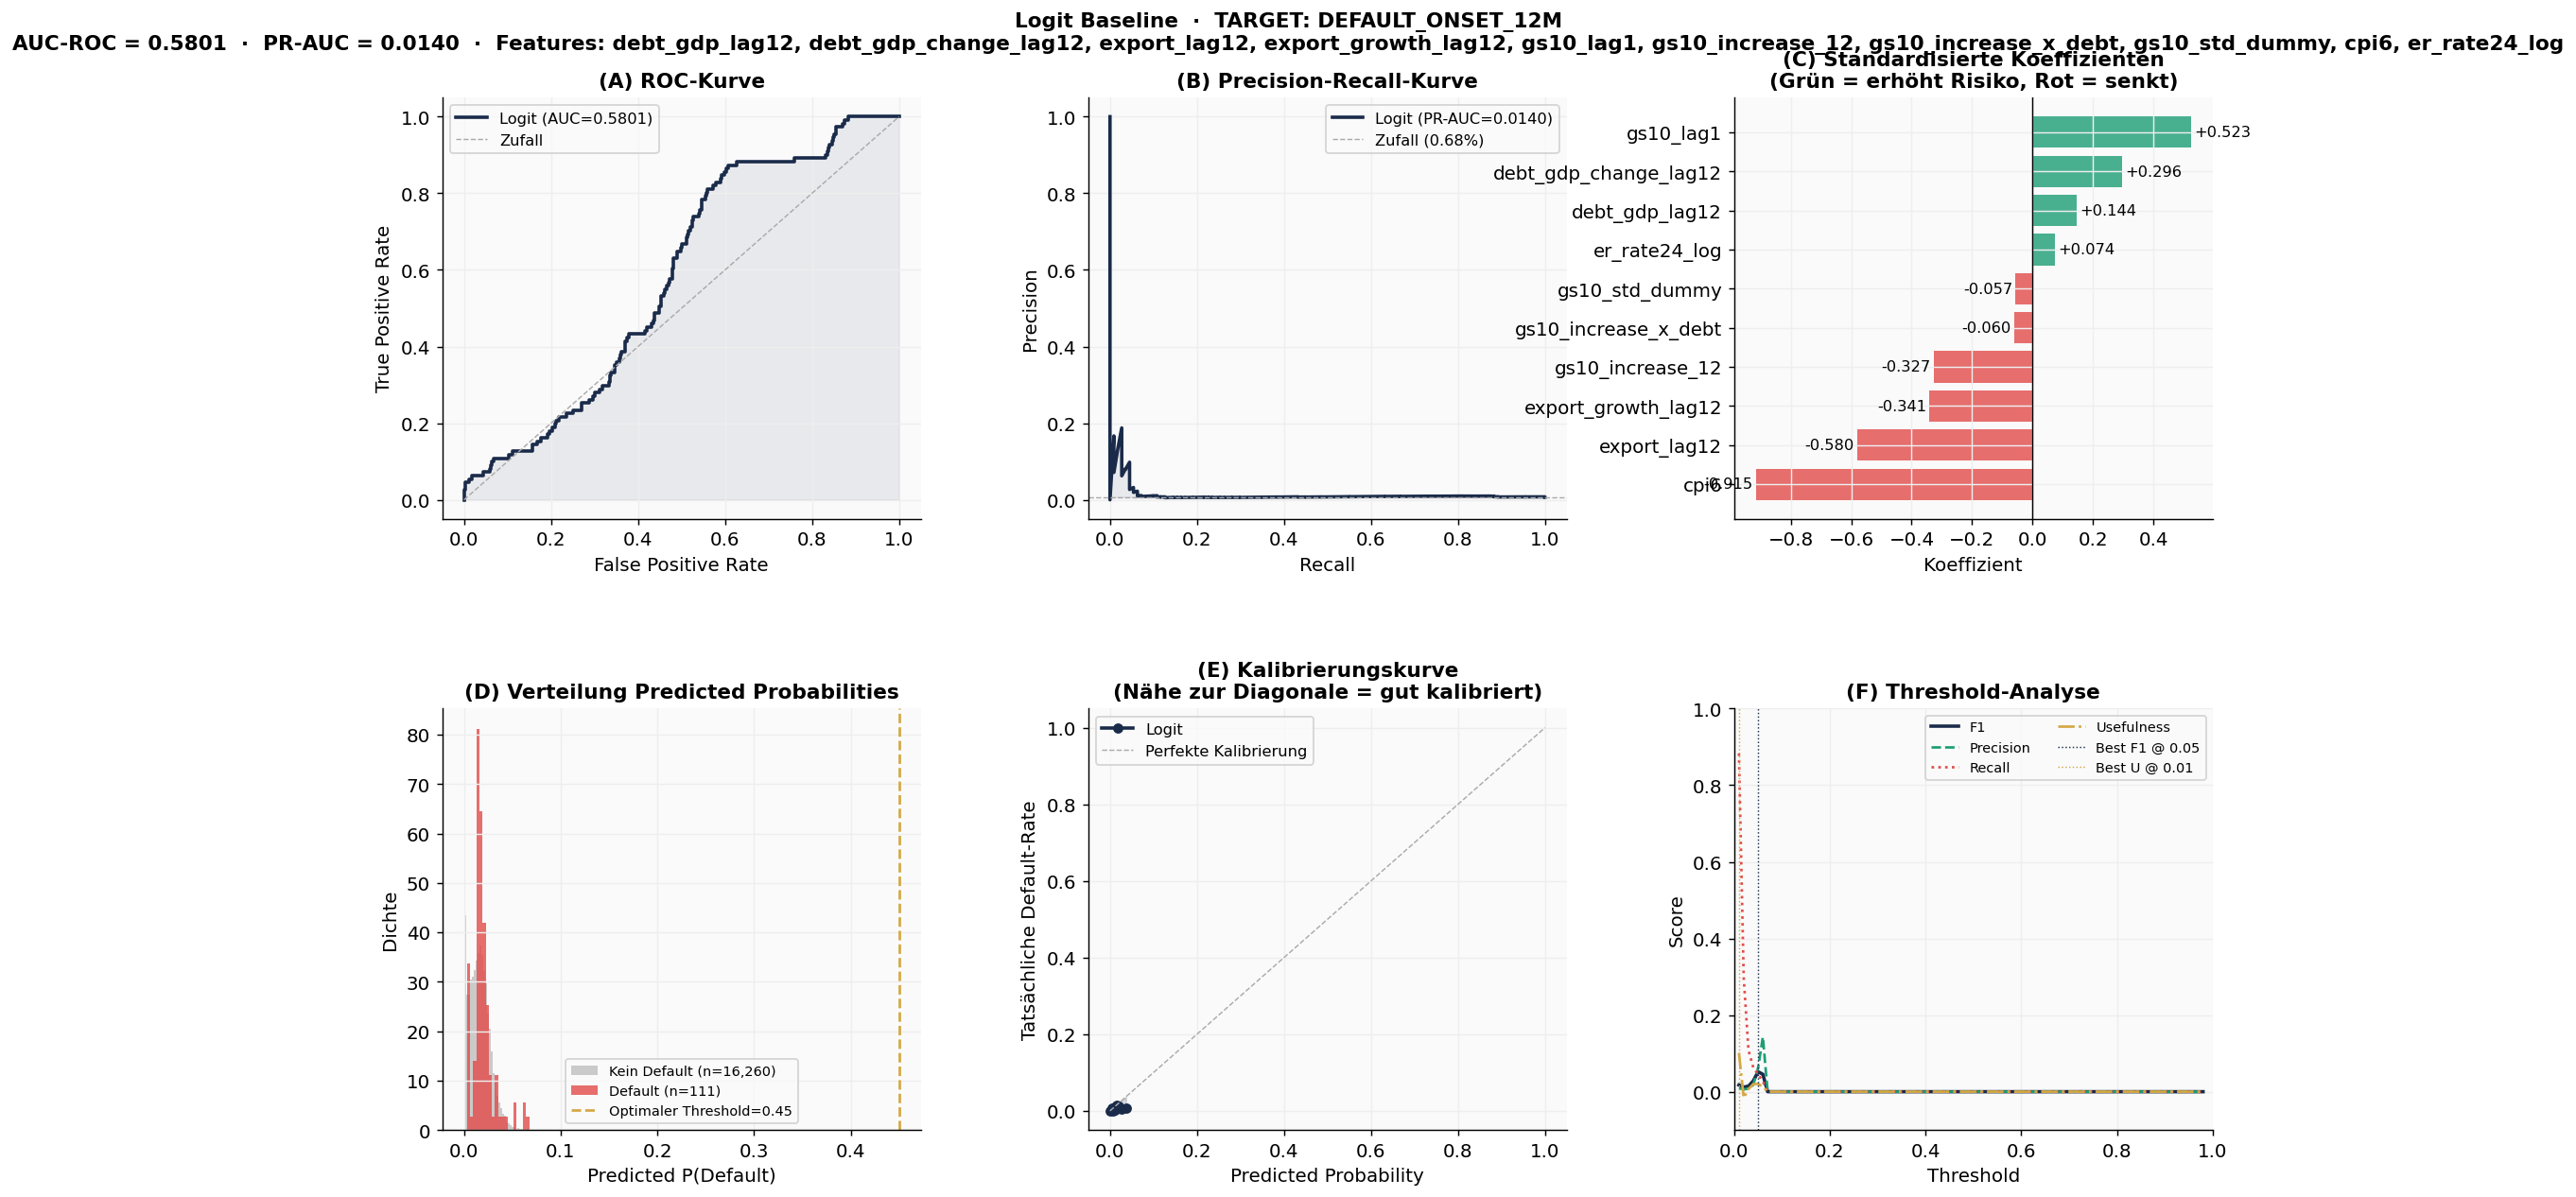


LOGIT ZUSAMMENFASSUNG
Features:     debt_gdp_lag12, debt_gdp_change_lag12, export_lag12, export_growth_lag12, gs10_lag1, gs10_increase_12, gs10_increase_x_debt, gs10_std_dummy, cpi6, er_rate24_log
AUC-ROC:      0.5801
PR-AUC:       0.0140

Optimaler Threshold:
  Nach F1:         0.05 (F1=0.052)
  Nach Usefulness: 0.01 (U=0.101)

Bei Threshold = 0.05:
  TP=5  FP=76  FN=106  TN=16184
  Precision: 0.062
  Recall:    0.045
  F1:        0.052
→ Diese Werte sind dein Benchmark für XGBoost.


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Logit Ergebnis-Visualisierung
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#EEEEEE",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "figure.dpi":        130,
})

C = {"logit": "#1A2B4A", "zero": "#AAAAAA",
     "pos": "#1D9E75", "neg": "#E24B4A", "gold": "#D4A843"}

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f"Logit Baseline  ·  TARGET: {FORECAST_TARGET}\n"
    f"AUC-ROC = {auc_roc_l:.4f}  ·  PR-AUC = {auc_pr_l:.4f}  ·  "
    f"Features: {', '.join(logit_features)}",
    fontsize=12, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.45, wspace=0.35,
                       left=0.07, right=0.97,
                       top=0.92, bottom=0.08)

# ── Panel A: ROC-Kurve ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test_l, y_pred_logit)
ax.plot(fpr, tpr, color=C["logit"], lw=2,
        label=f'Logit (AUC={auc_roc_l:.4f})')
ax.plot([0,1],[0,1], color=C["zero"], lw=0.8, ls='--', label='Zufall')
ax.fill_between(fpr, tpr, alpha=0.08, color=C["logit"])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('(A) ROC-Kurve')
ax.legend(fontsize=9)

# ── Panel B: Precision-Recall-Kurve ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
prec, rec, _ = precision_recall_curve(y_test_l, y_pred_logit)
ax.plot(rec, prec, color=C["logit"], lw=2,
        label=f'Logit (PR-AUC={auc_pr_l:.4f})')
baseline_pr = y_test_l.mean()
ax.axhline(baseline_pr, color=C["zero"], lw=0.8, ls='--',
           label=f'Zufall ({baseline_pr:.2%})')
ax.fill_between(rec, prec, baseline_pr, alpha=0.08, color=C["logit"])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('(B) Precision-Recall-Kurve')
ax.legend(fontsize=9)

# ── Panel C: Odds-Ratio-Plot ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])

# Koeffizienten aus sklearn-Modell (standardisiert)
coefs = pd.Series(
    logit_model.coef_[0],
    index=logit_features
).sort_values()

# Approximierte 95%-KI (aus Standardfehler der standardisierten Features)
# Für exakte KI: statsmodels verwenden
colors_bar = [C["pos"] if c > 0 else C["neg"] for c in coefs.values]
bars = ax.barh(coefs.index, coefs.values, color=colors_bar, alpha=0.8)

ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, coefs.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_title('(C) Standardisierte Koeffizienten\n(Grün = erhöht Risiko, Rot = senkt)')
ax.set_xlabel('Koeffizient')

# ── Panel D: Predicted Probability Verteilung ─────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
mask_pos = y_test_l == 1
mask_neg = y_test_l == 0

ax.hist(y_pred_logit[mask_neg], bins=40, alpha=0.6,
        color=C["zero"], label=f'Kein Default (n={mask_neg.sum():,})',
        density=True)
ax.hist(y_pred_logit[mask_pos], bins=20, alpha=0.8,
        color=C["neg"], label=f'Default (n={mask_pos.sum():,})',
        density=True)
ax.axvline(0.45, color=C["gold"], lw=1.5, ls='--',
           label='Optimaler Threshold=0.45')
ax.set_xlabel('Predicted P(Default)')
ax.set_ylabel('Dichte')
ax.set_title('(D) Verteilung Predicted Probabilities')
ax.legend(fontsize=8)

# ── Panel E: Kalibrierungskurve ───────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
fraction_pos, mean_pred = calibration_curve(
    y_test_l, y_pred_logit, n_bins=10, strategy='quantile'
)
ax.plot(mean_pred, fraction_pos, color=C["logit"], lw=2,
        marker='o', ms=5, label='Logit')
ax.plot([0,1],[0,1], color=C["zero"], lw=0.8, ls='--',
        label='Perfekte Kalibrierung')
ax.fill_between(mean_pred,
                fraction_pos, mean_pred,
                alpha=0.15, color=C["logit"])
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Tatsächliche Default-Rate')
ax.set_title('(E) Kalibrierungskurve\n(Nähe zur Diagonale = gut kalibriert)')
ax.legend(fontsize=9)

# ── Panel F: Threshold-Analyse ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])

thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores, prec_scores, rec_scores, u_scores = [], [], [], []

for t in thresholds:
    yb = (y_pred_logit >= t).astype(int)
    tp = ((yb==1)&(y_test_l==1)).sum()
    fp = ((yb==1)&(y_test_l==0)).sum()
    tn = ((yb==0)&(y_test_l==0)).sum()
    fn = ((yb==0)&(y_test_l==1)).sum()

    p  = tp/(tp+fp) if (tp+fp)>0 else 0
    r  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*p*r/(p+r) if (p+r)>0 else 0
    fpr_t = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr_t = fn/(fn+tp) if (fn+tp)>0 else 0
    u  = min(0.5, 0.5) - (0.5*fnr_t + 0.5*fpr_t)

    f1_scores.append(f1)
    prec_scores.append(p)
    rec_scores.append(r)
    u_scores.append(u)

ax.plot(thresholds, f1_scores,   color=C["logit"], lw=2, label='F1')
ax.plot(thresholds, prec_scores, color=C["pos"],   lw=1.5, ls='--',
        label='Precision')
ax.plot(thresholds, rec_scores,  color=C["neg"],   lw=1.5, ls=':',
        label='Recall')
ax.plot(thresholds, u_scores,    color=C["gold"],  lw=1.5, ls='-.',
        label='Usefulness')

best_f1_idx = np.argmax(f1_scores)
best_u_idx  = np.argmax(u_scores)
ax.axvline(thresholds[best_f1_idx], color=C["logit"], lw=0.8, ls=':',
           label=f'Best F1 @ {thresholds[best_f1_idx]:.2f}')
ax.axvline(thresholds[best_u_idx],  color=C["gold"],  lw=0.8, ls=':',
           label=f'Best U @ {thresholds[best_u_idx]:.2f}')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('(F) Threshold-Analyse')
ax.legend(fontsize=8, ncol=2)
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.0)

plt.savefig('logit_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Numerische Zusammenfassung ────────────────────────────────────────────────
print(f"\n{'='*55}")
print("LOGIT ZUSAMMENFASSUNG")
print(f"{'='*55}")
print(f"Features:     {', '.join(logit_features)}")
print(f"AUC-ROC:      {auc_roc_l:.4f}")
print(f"PR-AUC:       {auc_pr_l:.4f}")
print(f"\nOptimaler Threshold:")
print(f"  Nach F1:         {thresholds[best_f1_idx]:.2f} "
      f"(F1={f1_scores[best_f1_idx]:.3f})")
print(f"  Nach Usefulness: {thresholds[best_u_idx]:.2f} "
      f"(U={u_scores[best_u_idx]:.3f})")
print(f"\nBei Threshold = {thresholds[best_f1_idx]:.2f}:")
t_opt = thresholds[best_f1_idx]
yb = (y_pred_logit >= t_opt).astype(int)
tp = int(((yb==1)&(y_test_l==1)).sum())
fp = int(((yb==1)&(y_test_l==0)).sum())
fn = int(((yb==0)&(y_test_l==1)).sum())
tn = int(((yb==0)&(y_test_l==0)).sum())
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Precision: {tp/(tp+fp) if (tp+fp)>0 else 0:.3f}")
print(f"  Recall:    {tp/(tp+fn) if (tp+fn)>0 else 0:.3f}")
print(f"  F1:        {f1_scores[best_f1_idx]:.3f}")
print(f"{'='*55}")
print("→ Diese Werte sind dein Benchmark für XGBoost.")